# Matching - PySpark version

In [ ]:
# matching.py

import os
import json
import numpy as np
import pandas as pd

from typing import List, Optional, Dict, Any

from pyspark.sql import DataFrame, Window
from pyspark.sql import functions as F

In [9]:
%run ./matching_process

StatementMeta(, 271729ff-b35c-4fb7-a11d-203cf0b6d01b, 16, Finished, Available, Finished, True)

In [7]:
%run ./prepare_matching_data

StatementMeta(, 271729ff-b35c-4fb7-a11d-203cf0b6d01b, 14, Finished, Available, Finished, True)

In [3]:
%run ./matching_validation

StatementMeta(, 271729ff-b35c-4fb7-a11d-203cf0b6d01b, 8, Finished, Available, Finished, True)

In [1]:
%run ./consumption_cohort

StatementMeta(, 091e3bb7-049e-4781-957f-d5c5106e4250, 3, Finished, Available, Finished, True)

## Load Data

In [4]:
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")
month_result_all= month_result[month_result["price"]== "high"] 
print(month_result.shape)
print(month_result_all.shape)
month_result_spark= spark.createDataFrame(month_result_all)

StatementMeta(, 271729ff-b35c-4fb7-a11d-203cf0b6d01b, 10, Finished, Available, Finished, False)

(4538578, 17)
(829808, 17)


In [5]:
month_result_spark.show()

StatementMeta(, 271729ff-b35c-4fb7-a11d-203cf0b6d01b, 11, Finished, Available, Finished, False)

+------------------+-------------------+-----+-------------+-------------------+-----------------+-------------------+-----------------+-------------------+-----------------+---------------------+--------------------+----------------+------------+-----------+-----------------+-----------+
|               aID|           TIDPUNKT|price|tariff_active|         peak1_time|peak1_consumption|         peak2_time|peak2_consumption|         peak3_time|peak3_consumption|top3_mean_consumption|variance_consumption|mean_consumption|tariff_start|tariff_plan|total_consumption|usage_group|
+------------------+-------------------+-----+-------------+-------------------+-----------------+-------------------+-----------------+-------------------+-----------------+---------------------+--------------------+----------------+------------+-----------+-----------------+-----------+
|735999166200085868|2025-01-01 00:00:00| high|            0|2025-01-17 18:00:00|       1.72700000|2025-01-16 18:00:00|       1.640

In [10]:
month_result_all

StatementMeta(, 49dd3616-094f-463a-84fd-e32fc3c3987e, 16, Finished, Available, Finished, False)

,aID,TIDPUNKT,price,tariff_active,peak1_time,peak1_consumption,peak2_time,peak2_consumption,peak3_time,peak3_consumption,top3_mean_consumption,variance_consumption,mean_consumption,tariff_start,tariff_plan,total_consumption,usage_group
5,735999166200085868,2025-01-01,high,0,2025-01-17 18:00:00,1.72700000,2025-01-16 18:00:00,1.64000000,2025-01-30 18:00:00,1.56400000,1.643667,0.108457,0.331809523810,NaT,None,7459.16400000,low
16,735999166200085868,2026-01-01,high,0,2026-01-26 13:00:00,1.38900000,2026-01-13 08:00:00,1.33400000,2026-01-20 18:00:00,1.31600000,1.346333,0.112494,0.326250000000,NaT,None,7459.16400000,low
17,735999166200085868,2024-11-01,high,0,2024-11-21 18:00:00,2.05800000,2024-11-18 19:00:00,1.56400000,2024-11-26 19:00:00,1.53900000,1.720333,0.091320,0.372366300366,NaT,None,7459.16400000,low
24,735999166200085868,2023-12-01,high,0,2023-12-12 18:00:00,1.77100000,2023-12-05 11:00:00,1.28400000,2023-12-11 13:00:00,1.24400000,1.433000,0.083415,0.286805668016,NaT,None,7459.16400000,low
25,735999166200085868,2026-02-01,high,0,2026-02-13 15:00:00,2.35200000,2026-02-09 15:00:00,1.84100000,2026-02-10 14:00:00,1.78400000,1.992333,0.222518,0.584076923077,NaT,None,7459.16400000,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4538556,735999166300928010,2026-02-01,high,0,2026-02-18 11:00:00,6.89100000,2026-02-09 11:00:00,6.45800000,2026-02-04 17:00:00,6.42400000,6.591000,2.268373,3.149230769231,NaT,None,25498.93100000,medium
4538558,735999166300928010,2024-12-01,high,0,2024-12-10 12:00:00,6.76900000,2024-12-04 11:00:00,5.36000000,2024-12-30 13:00:00,5.26900000,5.799333,1.752208,2.115841880342,NaT,None,25498.93100000,medium
4538561,735999166300928010,2024-11-01,high,0,2024-11-21 10:00:00,5.58600000,2024-11-22 09:00:00,5.14700000,2024-11-29 08:00:00,3.83400000,4.855667,1.175886,1.572556776557,NaT,None,25498.93100000,medium
4538573,735999166300928010,2025-01-01,high,0,2025-01-02 12:00:00,8.62200000,2025-01-13 19:00:00,6.81200000,2025-01-07 19:00:00,5.12200000,6.852000,1.578426,1.826509157509,NaT,None,25498.93100000,medium


## Matching


StatementMeta(, 49dd3616-094f-463a-84fd-e32fc3c3987e, 20, Finished, Available, Finished, True)

Preparing full risk set (for calendar matching)...
Preparing base data...
Building risk set...
risk_rows count = 4732751
Running calendar matching (k=5)...
Running calendar-aligned matching...
risk_rows count = 4732751
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|471053|
|2025-03-01|treated|6237  |
|2025-04-01|control|471629|
|2025-04-01|treated|3340  |
|2025-05-01|control|471629|
|2025-05-01|treated|1400  |
|2025-06-01|control|471629|
|2025-06-01|treated|1250  |
|2025-07-01|control|471629|
|2025-07-01|treated|640   |
|2025-08-01|control|471629|
|2025-08-01|treated|400   |
|2025-09-01|control|471629|
|2025-09-01|treated|490   |
|2025-10-01|control|471629|
|2025-10-01|treated|500   |
|2025-11-01|control|471629|
|2025-11-01|treated|1464  |
|2025-12-01|control|471735|
|2025-12-01|treated|1210  |
+----------+-------+------+

Building calendar-aligned profiles ...
profiles count = 473665
Standardizing by controls ...
profiles_z coun

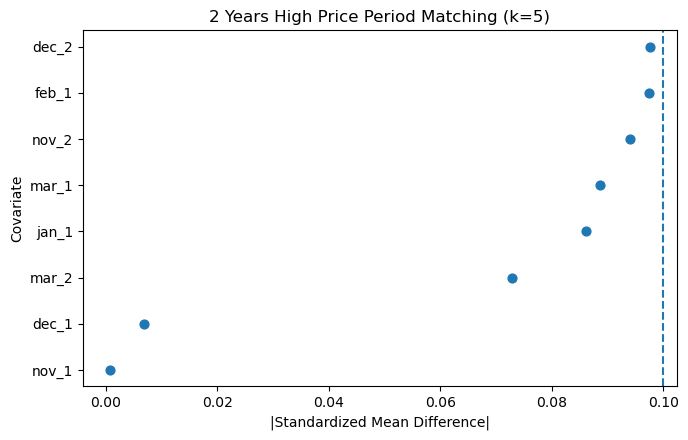

Rebuilding validation data...
  Matching vars window:     [t-24, t-0)
  Non-matching vars window: [t-24, t-0)
Validation rows (matching vars) count = 81003
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 81003
Profiles rebuilt for non-matching vars

(No matching variables available)

------------------------------------------------------------


=== NON-MATCHING VARIABLES CHECK [24, 0) ===

--- OVERALL ---
+--------------------+--------------------+--------------------+--------------------+
|covariate           |treated_mean        |control_mean        |SMD                 |
+--------------------+--------------------+--------------------+--------------------+
|peak_mean           |5.148964238013295   |5.02835814261092    |0.04960960727131684 |
|peak_sd             |1.1374120041435904  |0.8905016016761517  |0.3357179857282696  |
|peak_volatility     |1.0522752596197968  |0.8178682235573637  |0.36214764053471926 |
|mean_consumption    |1.7255284628639622  |

In [13]:

# ============================================================
# Step 1: FULL risk set（calendar 必須用完整月份）
# ============================================================

print("Preparing full risk set (for calendar matching)...")

risk_rows_full = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=24,      # cover 2 years
    match_months=None,       # ❗不能限制月份
    control_type="never_treated",
    verbose=True,
    price_value="high"
)


# ============================================================
# Step 2: calendar matching (k = 5)
# ============================================================

print("Running calendar matching (k=5)...")

res_calendar2 = run_calendar_matching_aligned(
    risk_rows=risk_rows_full,   # ✅ 改這裡
    output_folder="Files/output/matching_high/calendar2",
    lookback_years=2,
    match_months=[1,2,3,11,12],
    k_neighbors=5,              
    verbose=True,
    save_output=False,
    control_type="never_treated"
)


# ============================================================
# Step 3: save
# ============================================================

save_matching_results_fabric(
    res=res_calendar2,
    folder="Files/output/matching_high/calendar2",
    config={
        "type": "calendar",
        "k_neighbors": 5,
        "match_months": [1,2,3,11,12]
    },
)


# ============================================================
# Step 4: love plot
# ============================================================

love_plot_from_spark(
    res_calendar2["balance"],
    output_path=None, 
    title="2 Years High Price Period Matching (k=5)"
)


# ============================================================
# Step 5: validation（🔥一定要有 sdf）
# ============================================================

check_balance_full_safe(
    res=res_calendar2,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=0,

    extra_start_month=24,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0,

    price_value="high"
)

StatementMeta(, 271729ff-b35c-4fb7-a11d-203cf0b6d01b, 19, Finished, Available, Finished, False)

Preparing full risk set (for calendar matching)...
Preparing base data...
Building risk set...
risk_rows count = 2368443
Running calendar matching (k=5)...
Running calendar-aligned matching...
risk_rows count = 2368443
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|235932|
|2025-03-01|treated|3124  |
|2025-04-01|control|236001|
|2025-04-01|treated|1670  |
|2025-05-01|control|236001|
|2025-05-01|treated|700   |
|2025-06-01|control|236001|
|2025-06-01|treated|625   |
|2025-07-01|control|236001|
|2025-07-01|treated|320   |
|2025-08-01|control|236001|
|2025-08-01|treated|200   |
|2025-09-01|control|236001|
|2025-09-01|treated|245   |
|2025-10-01|control|236001|
|2025-10-01|treated|250   |
|2025-11-01|control|236001|
|2025-11-01|treated|737   |
|2025-12-01|control|236027|
|2025-12-01|treated|605   |
+----------+-------+------+

Building calendar-aligned profiles ...
profiles count = 473646
Standardizing by controls ...
profiles_z coun

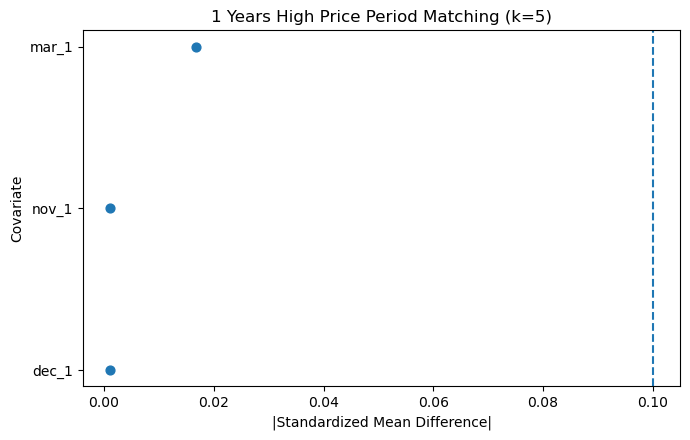

Rebuilding validation data...
  Matching vars window:     [t-24, t-12)
  Non-matching vars window: [t-12, t-0)
Validation rows (matching vars) count = 45849
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 46071
Profiles rebuilt for non-matching vars

(No matching variables available)

------------------------------------------------------------


=== NON-MATCHING VARIABLES CHECK [12, 0) ===

--- OVERALL ---
+--------------------+---------------------+-------------------+--------------------+
|covariate           |treated_mean         |control_mean       |SMD                 |
+--------------------+---------------------+-------------------+--------------------+
|peak_mean           |4.972180136118171    |5.008525363815875  |-0.01507081458576106|
|peak_sd             |0.9371387981089453   |0.8077007670757397 |0.17779355451939668 |
|peak_volatility     |1.0101005775624734   |0.8716784613464974 |0.17262015299869887 |
|mean_consumption    |1.580604359129842   

In [12]:
# 1 year
# ============================================================
# Step 1: FULL risk set（calendar 必須用完整月份）
# ============================================================

print("Preparing full risk set (for calendar matching)...")

risk_rows_full = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=12,      # cover 2 years
    match_months=None,       # ❗不能限制月份
    control_type="never_treated",
    verbose=True,
    price_value="high"
)


# ============================================================
# Step 2: calendar matching (k = 5)
# ============================================================

print("Running calendar matching (k=5)...")

res_calendar2 = run_calendar_matching_aligned(
    risk_rows=risk_rows_full,   # ✅ 改這裡
    output_folder="Files/output/matching_high/calendar2_1year",
    lookback_years=1,
    match_months=[1,2,3,11,12],
    k_neighbors=5,              
    verbose=True,
    save_output=False,
    control_type="never_treated"
)


# ============================================================
# Step 3: save
# ============================================================

save_matching_results_fabric(
    res=res_calendar2,
    folder="Files/output/matching_high/calendar2_1year",
    config={
        "type": "calendar",
        "k_neighbors": 5,
        "match_months": [1,2,3,11,12]
    },
)


# ============================================================
# Step 4: love plot
# ============================================================

love_plot_from_spark(
    res_calendar2["balance"],
    output_path=None, 
    title="1 Years High Price Period Matching (k=5)"
)


# ============================================================
# Step 5: validation（🔥一定要有 sdf）
# ============================================================

check_balance_full_safe(
    res=res_calendar2,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=12,

    extra_start_month=12,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0,

    price_value="high"
)

StatementMeta(, 271729ff-b35c-4fb7-a11d-203cf0b6d01b, 18, Finished, Available, Finished, False)

Running summary matching 4...
Preparing base data...
Building risk set...
risk_rows count = 2368443
risk_rows count = 2368443
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|235932|
|2025-03-01|treated|3124  |
|2025-04-01|control|236001|
|2025-04-01|treated|1670  |
|2025-05-01|control|236001|
|2025-05-01|treated|700   |
|2025-06-01|control|236001|
|2025-06-01|treated|625   |
|2025-07-01|control|236001|
|2025-07-01|treated|320   |
|2025-08-01|control|236001|
|2025-08-01|treated|200   |
|2025-09-01|control|236001|
|2025-09-01|treated|245   |
|2025-10-01|control|236001|
|2025-10-01|treated|250   |
|2025-11-01|control|236001|
|2025-11-01|treated|737   |
|2025-12-01|control|236027|
|2025-12-01|treated|605   |
+----------+-------+------+

Building summary profiles ...
profiles count = 473779
Standardizing by controls ...
profiles_z count = 473779
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles coun

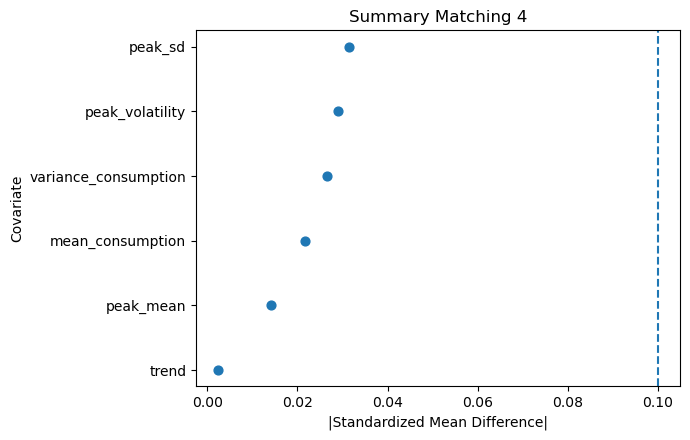

Rebuilding validation data...
  Matching vars window:     [t-24, t-12)
  Non-matching vars window: [t-12, t-0)
Validation rows (matching vars) count = 49196
Profiles rebuilt for matching vars
Validation rows (non-matching vars) count = 49343
Profiles rebuilt for non-matching vars

=== MATCHING VARIABLES CHECK [24, 12) ===

--- OVERALL ---
+--------------------+-------------------+--------------------+--------------------+
|covariate           |treated_mean       |control_mean        |SMD                 |
+--------------------+-------------------+--------------------+--------------------+
|peak_mean           |5.33505939090372   |5.10275128086745    |0.09107366590448303 |
|peak_sd             |0.9902249765413148 |0.903290806355235   |0.11858039736146776 |
|peak_volatility     |1.071176914402441  |0.9791818499121515  |0.11421918484756796 |
|mean_consumption    |1.8622304875744526 |1.813494288797066   |0.04683746726462338 |
|variance_consumption|1.1879730750614792 |1.1020041364303303  |0

In [11]:
print("Running summary matching 4...")

# ============================================================
# STEP 0: build risk_rows（🔥必要）
# ============================================================
risk_rows = prepare_matching_data(
    sdf=month_result_spark,
    lookback_months=12,
    control_type="never_treated",
    verbose=True,
    price_value="high"
)

# ============================================================
# STEP 1: matching（🔥改成用 risk_rows）
# ============================================================
res_summary_4 = run_summary_matching_pipeline(
    output_folder="Files/output/matching_high/summary_4",
    risk_rows=risk_rows,   # 🔥關鍵修正
    lookback_months=12,
    summary_vars=[
        "peak_mean",
        "peak_sd",
        "peak_volatility",
        "mean_consumption",
        "variance_consumption",
        "trend"
    ],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# ============================================================
# STEP 2: save（OK）
# ============================================================
save_matching_results_fabric(
    res=res_summary_4,
    folder="Files/output/matching_high/summary_4",
    config={
        "type": "summary",
        "vars": [
            "peak_mean",
            "peak_sd",
            "peak_volatility",
            "mean_consumption",
            "variance_consumption",
            "trend"
        ]
    },
)

# ============================================================
# STEP 3: love plot（OK）
# ============================================================
love_plot_from_spark(
    res_summary_4["balance"],
    output_path=None,
    title="Summary Matching 4"
)

# ============================================================
# STEP 4: validation（🔥一定要加 sdf）
# ============================================================
check_balance_full_safe(
    res=res_summary_4,
    sdf=month_result_spark,

    match_start_month=24,
    match_end_month=12,

    extra_start_month=12,
    extra_end_month=0,

    calendar_start_month=24,
    calendar_end_month=0,

    price_value="high"
)